# Assignment 06: RNN Foundations in PyTorch



## Structure
- Part A: Manual RNN calculation
- Part B: Reproduce the same RNN in PyTorch
- Part C: DNA sequence classifier
- Follow-up questions

In [ ]:
# If torch is not installed in this notebook kernel, install it first.
import importlib.util
import sys

if importlib.util.find_spec('torch') is None:
    print('Installing PyTorch...')
    !{sys.executable} -m pip install torch -q

import math
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print('Torch version:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Reproducibility
random.seed(42)
torch.manual_seed(42)

Torch version: 2.10.0+cpu
Device: cpu


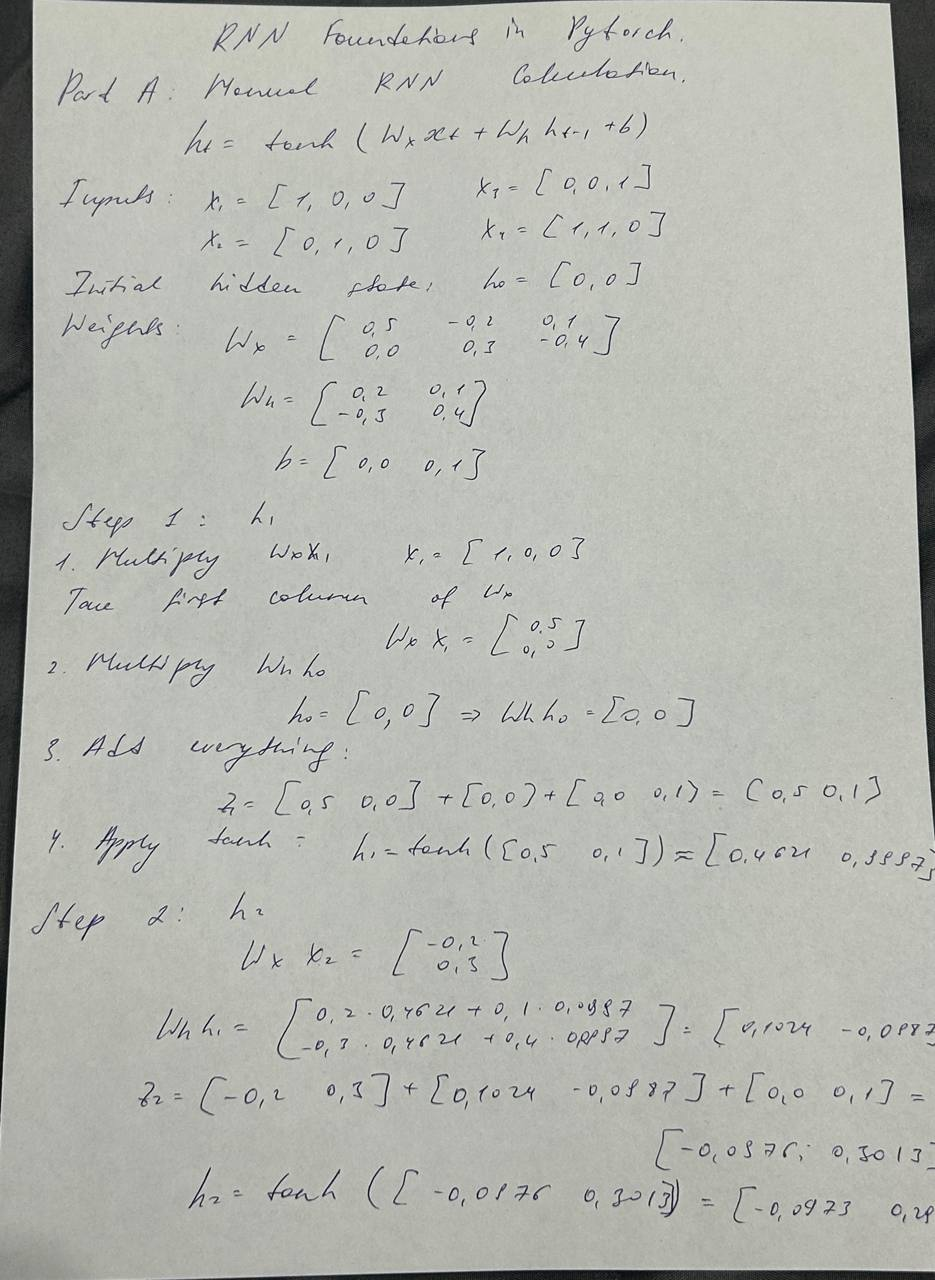

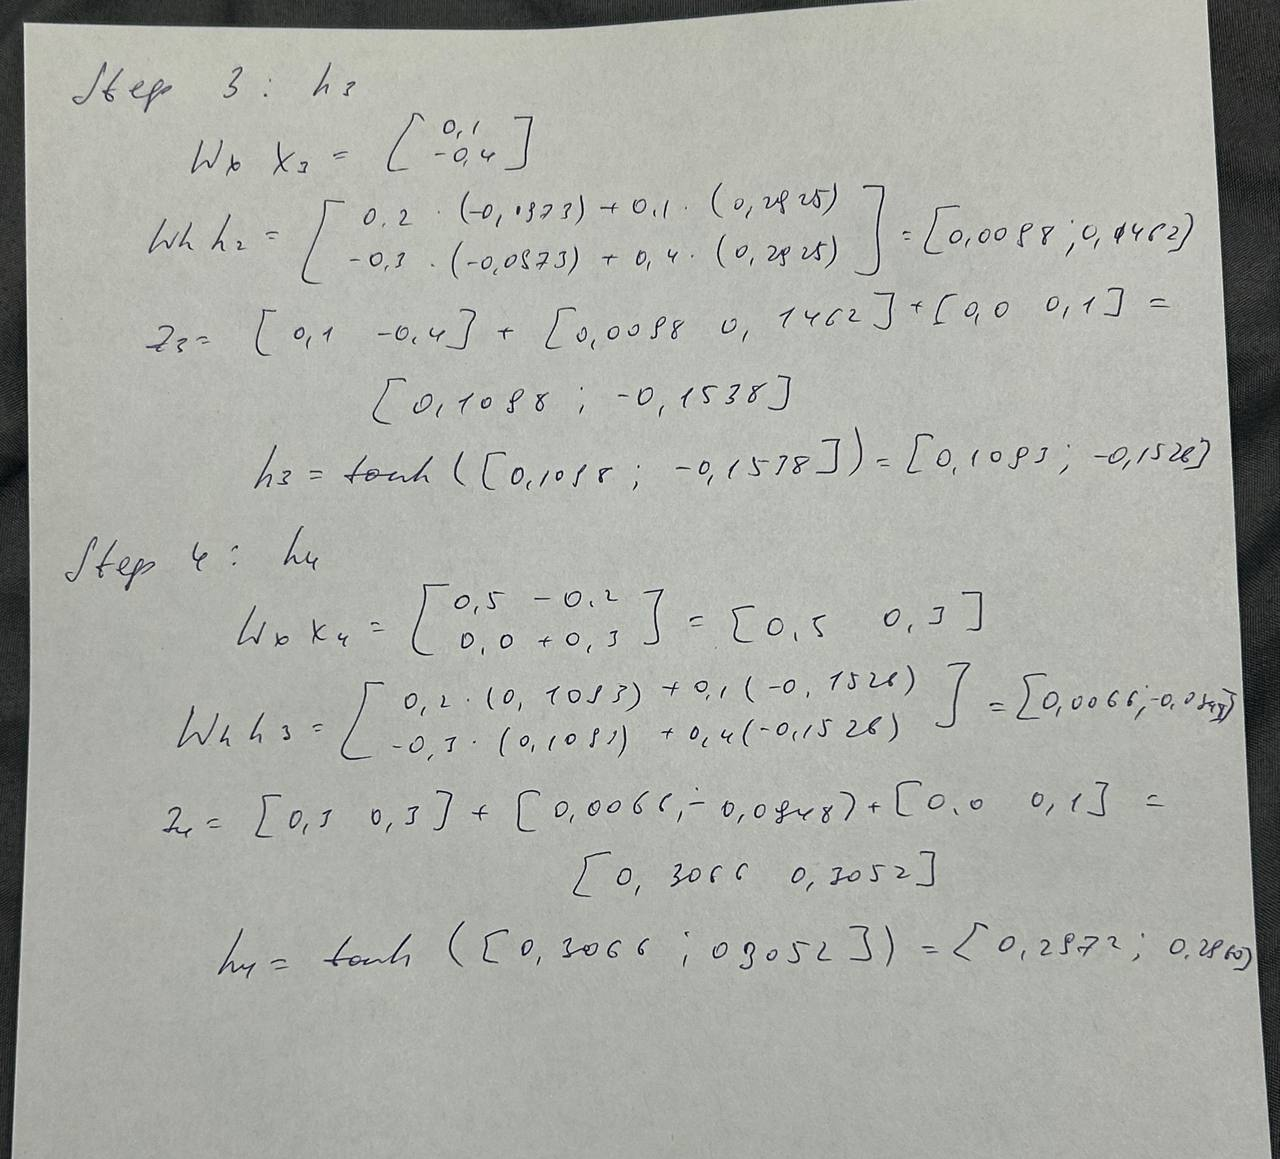

## Part A: Manual RNN Calculation

Given:

- $x_1 = [1.0, 0.0, 0.0]$
- $x_2 = [0.0, 1.0, 0.0]$
- $x_3 = [0.0, 0.0, 1.0]$
- $x_4 = [1.0, 1.0, 0.0]$
- $h_0 = [0.0, 0.0]$

Update rule:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

We will compute each step with pre-activation and final hidden state.

In [ ]:
# Part A: manual computation with plain Python lists

x_list = [
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 1.0, 0.0],
]

W_x = [
    [0.5, -0.2, 0.1],
    [0.0, 0.3, -0.4],
]
W_h = [
    [0.2, 0.1],
    [-0.3, 0.4],
]
b = [0.0, 0.1]

h_prev = [0.0, 0.0]
all_h = []

for t, x_t in enumerate(x_list, start=1):
    wx_xt = [0.0, 0.0]
    wh_ht = [0.0, 0.0]
    pre = [0.0, 0.0]

    for r in range(2):
        # Separate each component for clear step-by-step explanation
        wx_xt[r] = W_x[r][0] * x_t[0] + W_x[r][1] * x_t[1] + W_x[r][2] * x_t[2]
        wh_ht[r] = W_h[r][0] * h_prev[0] + W_h[r][1] * h_prev[1]
        pre[r] = wx_xt[r] + wh_ht[r] + b[r]

    h_t = [math.tanh(pre[0]), math.tanh(pre[1])]
    all_h.append(h_t)

    print(f'Step t={t}')
    print('x_t =', x_t)
    print('W_x x_t        =', [round(v, 6) for v in wx_xt])
    print('W_h h_{t-1}    =', [round(v, 6) for v in wh_ht])
    print('bias b         =', b)
    print('pre-activation =', [round(v, 6) for v in pre])
    print('h_t = tanh(...)=', [round(v, 6) for v in h_t])
    print('-' * 50)

    h_prev = h_t

h1, h2, h3, h4 = all_h
print('Final values:')
print('h1 =', [round(v, 6) for v in h1])
print('h2 =', [round(v, 6) for v in h2])
print('h3 =', [round(v, 6) for v in h3])
print('h4 =', [round(v, 6) for v in h4])

Step t=1
x_t = [1.0, 0.0, 0.0]
W_x x_t        = [0.5, 0.0]
W_h h_{t-1}    = [0.0, 0.0]
bias b         = [0.0, 0.1]
pre-activation = [0.5, 0.1]
h_t = tanh(...)= [0.462117, 0.099668]
--------------------------------------------------
Step t=2
x_t = [0.0, 1.0, 0.0]
W_x x_t        = [-0.2, 0.3]
W_h h_{t-1}    = [0.10239, -0.098768]
bias b         = [0.0, 0.1]
pre-activation = [-0.09761, 0.301232]
h_t = tanh(...)= [-0.097301, 0.29244]
--------------------------------------------------
Step t=3
x_t = [0.0, 0.0, 1.0]
W_x x_t        = [0.1, -0.4]
W_h h_{t-1}    = [0.009784, 0.146166]
bias b         = [0.0, 0.1]
pre-activation = [0.109784, -0.153834]
h_t = tanh(...)= [0.109345, -0.152632]
--------------------------------------------------
Step t=4
x_t = [1.0, 1.0, 0.0]
W_x x_t        = [0.3, 0.3]
W_h h_{t-1}    = [0.006606, -0.093856]
bias b         = [0.0, 0.1]
pre-activation = [0.306606, 0.306144]
h_t = tanh(...)= [0.297346, 0.296925]
--------------------------------------------------
Final v

### Part A Interpretation
Each hidden state depends on two things:
1. current input $x_t$
2. previous memory $h_{t-1}$

So information is passed step by step through time.

## Part B: Reproduce the Same RNN in PyTorch
We now build the same RNN using `nn.RNN(input_size=3, hidden_size=2, batch_first=True)` and set the weights to match Part A.

In [ ]:
# Build input tensor with shape (batch_size=1, seq_len=4, input_size=3)
x = torch.tensor([
    [
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, 1.0],
        [1.0, 1.0, 0.0],
    ]
], dtype=torch.float32)

rnn = nn.RNN(input_size=3, hidden_size=2, batch_first=True, nonlinearity='tanh')

# Set RNN parameters to exactly match Part A
with torch.no_grad():
    rnn.weight_ih_l0.copy_(torch.tensor(W_x, dtype=torch.float32))
    rnn.weight_hh_l0.copy_(torch.tensor(W_h, dtype=torch.float32))

    # PyTorch uses bias_ih + bias_hh. We keep bias_hh=0 and put b into bias_ih.
    rnn.bias_ih_l0.copy_(torch.tensor(b, dtype=torch.float32))
    rnn.bias_hh_l0.zero_()

h0 = torch.zeros(1, 1, 2)  # (num_layers, batch, hidden_size)
output, h_n = rnn(x, h0)

print('x.shape      :', tuple(x.shape))
print('output.shape :', tuple(output.shape))
print('h_n.shape    :', tuple(h_n.shape))
print('\noutput:')
print(output)
print('\nh_n:')
print(h_n)

print('\noutput[:, -1, :]:', output[:, -1, :])
print('h_n[-1]       :', h_n[-1])

x.shape      : (1, 4, 3)
output.shape : (1, 4, 2)
h_n.shape    : (1, 1, 2)

output:
tensor([[[ 0.4621,  0.0997],
         [-0.0973,  0.2924],
         [ 0.1093, -0.1526],
         [ 0.2973,  0.2969]]], grad_fn=<TransposeBackward1>)

h_n:
tensor([[[0.2973, 0.2969]]], grad_fn=<StackBackward0>)

output[:, -1, :]: tensor([[0.2973, 0.2969]], grad_fn=<SelectBackward0>)
h_n[-1]       : tensor([[0.2973, 0.2969]], grad_fn=<SelectBackward0>)


### Part B Answers (Detailed)

1. **What does `output[:, -1, :]` represent?**

   - `output` stores hidden states for **every time step**.
   - Shape with `batch_first=True`: `(batch, seq_len, hidden_size)`.
   - So `output[:, -1, :]` means:
     - take all samples in batch (`:`),
     - take the **last time step** (`-1`),
     - take all hidden features (`:`).
   - In words: this is the model's representation after reading the full sequence.

2. **What does `h_n[-1]` represent?**

   - `h_n` is the final hidden state returned by RNN.
   - Shape: `(num_layers, batch, hidden_size)`.
   - `h_n[-1]` means "final hidden state of the **last RNN layer**" for all samples.
   - In sequence classification, this is often the vector sent to the classifier.

3. **Why are they usually the same for a one-layer RNN?**

   - For one-layer vanilla RNN:
     - last output in time = final hidden state of that layer.
   - So `output[:, -1, :]` and `h_n[-1]` contain the same information.
   - They can differ in more complex setups (multiple layers, bidirectional processing, packing/unpacking details).

4. **What changes if `batch_first=False`?**

   - Input layout changes from `(batch, seq_len, input_size)` to `(seq_len, batch, input_size)`.
   - Output layout changes from `(batch, seq_len, hidden_size)` to `(seq_len, batch, hidden_size)`.
   - Computation logic does **not** change. Only tensor axis order changes.
   - Practical effect: indexing last time step becomes `output[-1, :, :]` instead of `output[:, -1, :]`.

## Part C: DNA Sequence Classifier
We will solve a many-to-one classification task: sequence -> label (contains motif or not).

Pipeline: DNA ids -> Embedding -> RNN -> Final hidden state -> Linear classifier

In [ ]:
# C1. Generate synthetic DNA data

alphabet = ['A', 'C', 'G', 'T']
motif = 'ATG'

char2idx = {'A': 0, 'C': 1, 'G': 2, 'T': 3, '<PAD>': 4}
idx2char = {v: k for k, v in char2idx.items()}
pad_idx = char2idx['<PAD>']

def random_dna(length):
    return ''.join(random.choice(alphabet) for _ in range(length))

def contains_motif(seq, motif):
    return motif in seq

def inject_motif(seq, motif, position=None):
    # Insert motif at a random or specified valid position
    if len(seq) < len(motif):
        return motif
    if position is None:
        position = random.randint(0, len(seq) - len(motif))
    return seq[:position] + motif + seq[position + len(motif):]

def make_one_example(min_len=30, max_len=80):
    length = random.randint(min_len, max_len)
    label = random.randint(0, 1)

    if label == 1:
        seq = random_dna(length)
        seq = inject_motif(seq, motif)
    else:
        # Keep sampling until motif is absent
        seq = random_dna(length)
        while contains_motif(seq, motif):
            seq = random_dna(length)

    return seq, label

def make_dataset(n):
    data = [make_one_example() for _ in range(n)]
    return data

train_data = make_dataset(2000)
val_data = make_dataset(500)
test_data = make_dataset(500)

print('Train size:', len(train_data))
print('Val size  :', len(val_data))
print('Test size :', len(test_data))
print('Example train sample:', train_data[0])

Train size: 2000
Val size  : 500
Test size : 500
Example train sample: ('GTGACGCTTTCGCCGTTGCCTAAACCTATTTGAAGGAGTCTAGCAGCCGCAGTAAGGCACAATACCTCGT', 0)


In [ ]:
# C2. Encode and pad variable-length sequences

def encode_seq(seq):
    return [char2idx[ch] for ch in seq]

class DNADataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        seq, label = self.pairs[idx]
        ids = encode_seq(seq)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    # batch is a list of (ids_tensor, label_tensor)
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    max_len = lengths.max().item()

    x_batch = torch.full((len(seqs), max_len), pad_idx, dtype=torch.long)
    for i, s in enumerate(seqs):
        x_batch[i, :len(s)] = s

    y_batch = torch.stack(labels)
    return x_batch, lengths, y_batch

train_loader = DataLoader(DNADataset(train_data), batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(DNADataset(val_data), batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(DNADataset(test_data), batch_size=64, shuffle=False, collate_fn=collate_fn)

# Show required shapes from one batch
x_batch, lengths, y_batch = next(iter(train_loader))
print('x_batch shape:', tuple(x_batch.shape))
print('lengths shape:', tuple(lengths.shape))
print('y_batch shape:', tuple(y_batch.shape))

x_batch shape: (64, 80)
lengths shape: (64,)
y_batch shape: (64,)


In [ ]:
# C3. Model: Embedding -> RNN -> final hidden state -> classifier

class DNAClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)

        # Packing skips padded positions during recurrent computation
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        _, h_n = self.rnn(packed)
        last_hidden = h_n[-1]
        logits = self.fc(last_hidden)
        return logits

model = DNAClassifier(
    vocab_size=len(char2idx),
    embed_dim=16,
    hidden_size=32,
    num_classes=2,
    pad_idx=pad_idx,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

print(model)

DNAClassifier(
  (embedding): Embedding(5, 16, padding_idx=4)
  (rnn): RNN(16, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


In [ ]:
# Training and evaluation helpers

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x_batch, lengths, y_batch in loader:
        x_batch = x_batch.to(device)
        lengths = lengths.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch, lengths)
        loss = criterion(logits, y_batch)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        total_correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
        total_count += x_batch.size(0)

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    return avg_loss, avg_acc

num_epochs = 8
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)
    print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

test_loss, test_acc = run_epoch(test_loader, model, criterion, optimizer=None)
print('\nFinal metrics:')
print(f'Training accuracy  : {train_acc:.4f}')
print(f'Validation accuracy: {val_acc:.4f}')
print(f'Test accuracy      : {test_acc:.4f}')

Epoch 01 | train_loss=0.7017 train_acc=0.5130 | val_loss=0.6916 val_acc=0.5400
Epoch 02 | train_loss=0.6924 train_acc=0.5360 | val_loss=0.6918 val_acc=0.5320
Epoch 03 | train_loss=0.6938 train_acc=0.5200 | val_loss=0.6912 val_acc=0.5280
Epoch 04 | train_loss=0.6880 train_acc=0.5505 | val_loss=0.6903 val_acc=0.5520
Epoch 05 | train_loss=0.6929 train_acc=0.5365 | val_loss=0.6933 val_acc=0.5220
Epoch 06 | train_loss=0.6938 train_acc=0.5325 | val_loss=0.6893 val_acc=0.5460
Epoch 07 | train_loss=0.6924 train_acc=0.5225 | val_loss=0.6905 val_acc=0.5400
Epoch 08 | train_loss=0.6941 train_acc=0.5200 | val_loss=0.6903 val_acc=0.5340

Final metrics:
Training accuracy  : 0.5200
Validation accuracy: 0.5340
Test accuracy      : 0.5040


In [ ]:
# C4. Generalization tests

def predict_one(seq):
    model.eval()
    ids = torch.tensor([encode_seq(seq)], dtype=torch.long).to(device)
    lengths = torch.tensor([len(seq)], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(ids, lengths)
        probs = torch.softmax(logits, dim=1)[0]
        pred = torch.argmax(probs).item()
        prob_1 = probs[1].item()
    return pred, prob_1

def build_case(base_len, where):
    seq = random_dna(base_len)
    if where == 'beginning':
        seq = motif + seq[len(motif):]
    elif where == 'middle':
        pos = (base_len // 2) - 1
        seq = inject_motif(seq, motif, max(0, min(pos, base_len - len(motif))))
    elif where == 'end':
        seq = seq[:-len(motif)] + motif
    elif where == 'long':
        seq = inject_motif(random_dna(120), motif, 70)
    elif where == 'noisy':
        noisy = 'AAAAA' + random_dna(base_len - 10) + 'TTTTT'
        seq = inject_motif(noisy, motif, 5)
    return seq

test_cases = [
    ('motif at beginning', build_case(50, 'beginning'), 1),
    ('motif in middle', build_case(50, 'middle'), 1),
    ('motif at end', build_case(50, 'end'), 1),
    ('motif in longer seq', build_case(50, 'long'), 1),
    ('motif with noisy repeats', build_case(50, 'noisy'), 1),
]

for name, seq, true_label in test_cases:
    pred, prob_1 = predict_one(seq)
    print('=' * 70)
    print('Case        :', name)
    print('Sequence    :', seq)
    print('True label  :', true_label)
    print('Pred label  :', pred)
    print('Prob(label=1):', round(prob_1, 4))

Case        : motif at beginning
Sequence    : ATGCCGTAATGCCAGTAAAAGGTCGACCTGATACTAACCGTCTCAAATAT
True label  : 1
Pred label  : 1
Prob(label=1): 0.5239
Case        : motif in middle
Sequence    : CATCTAATCTACCAGTTTCCAGGGATGCTAGTAACGTATACGCGTCCAGT
True label  : 1
Pred label  : 1
Prob(label=1): 0.5023
Case        : motif at end
Sequence    : GTGCTGGAGTTAGCTCATTGGTGGTAAGACGTCAAAGAAGGGGTGCAATG
True label  : 1
Pred label  : 1
Prob(label=1): 0.5787
Case        : motif in longer seq
Sequence    : CAAGCAGTTTGCGCCAAGGTAATCAACCGCTCGGGATCCTTCCCGTTCTTCAAAGCGATGCTTGAGATGGATGCAACCCCCATCATCGTAGGTAACAGGGCCGTCAAGAAAAAATTTATC
True label  : 1
Pred label  : 0
Prob(label=1): 0.4938
Case        : motif with noisy repeats
Sequence    : AAAAAATGACGTCGAAAGTATCCAGTCAAGGGGATTAGGAGAATATTTTT
True label  : 1
Pred label  : 1
Prob(label=1): 0.5401


### Part C Interpretation
- If train/val/test accuracy are high, the model learned the motif signal.
- Generalization tests check if the model detects the motif in different positions and conditions.
- If noisy or long cases are worse, that means vanilla RNN has limits with long or distracting context.

## Follow-up Questions

1. **Why do we use `nn.Embedding` before the RNN?**

   We start with token IDs like `A=0, C=1, ...`. These are just indices, not meaningful continuous features.
   `nn.Embedding` maps each ID to a trainable dense vector.

   Why it helps:
   - gives richer representation than raw IDs or sparse one-hot,
   - learns task-specific features during training,
   - usually improves convergence and final accuracy.

   Intuition: embedding is like a learned "feature dictionary" for symbols.

2. **Why is this a many-to-one task?**

   Input has many time steps (a full DNA sequence), but output is a single label (`contains motif` / `does not contain motif`).
   That is exactly the many-to-one setup: many inputs in time -> one prediction.

3. **Why do we use the final hidden state for classification?**

   The final hidden state is the RNN memory after reading the whole sequence.
   It summarizes what the model considered important across all steps.
   So it is a compact summary vector for the final classifier (`Linear` layer).

4. **Why do we pad sequences in a batch?**

   Different sequences have different lengths, but tensors in one batch must have the same shape.
   Padding makes short sequences the same length as the longest sequence in that batch.

   Without padding, we cannot efficiently process mixed-length samples in parallel.

5. **Why does `pack_padded_sequence` help?**

   Padding tokens are not real DNA content.
   If we do not pack, RNN still processes padded positions and this adds noise.

   `pack_padded_sequence` uses true lengths so recurrent computation ignores padded tail.
   Benefits:
   - cleaner learning signal,
   - less wasted computation,
   - often better accuracy.

6. **What can a vanilla RNN forget on long sequences?**

   It can forget early important information when sequence is long.
   This is related to vanishing gradients and weak long-range memory.

   In practice, model may focus too much on recent tokens and lose old context.

7. **What problem do LSTM/GRU solve?**

   LSTM/GRU are designed to improve long-term dependency learning.
   They control information flow with gates, so important signals can survive for more steps.

   Result: better memory on long sequences than vanilla RNN.

8. **What do gates do in LSTM/GRU?**

   Gates are learnable controllers that decide:
   - what to keep,
   - what to update,
   - what to forget.

   Intuition: gates work like smart filters for memory.
   This prevents memory from being overwritten by irrelevant information.

9. **If we replace `nn.RNN` with `nn.LSTM`, what extra output appears?**

   `nn.LSTM` returns:
   - `output` (hidden states over time),
   - `h_n` (final hidden state),
   - `c_n` (final cell state).

   Extra part is `c_n`, the cell-state memory used by LSTM for long-term information storage.

###  Summary

- Embedding converts IDs into trainable dense features.
- Task is many-to-one because one sequence gives one label.
- Final hidden state is sequence summary for classifier.
- Padding is needed for batching variable lengths.
- Packing prevents learning from `<PAD>` noise.
- Vanilla RNN struggles with long-term memory.
- LSTM/GRU use gates to keep important information longer.
- LSTM adds `c_n` (cell state) as extra memory output.